1. IMPORTS

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve
)
 
# Paleta PRT (consistente com os outros arquivos do projeto)
PRT_NAVY = "#19284F"   # não-churn
PRT_GREEN = "#39694B"  # churn
PRT_GRAY = "#737C8A"   # neutro
 
RANDOM_STATE = 42

2. CARREGAR DADOS

In [19]:
df = pd.read_csv("../bases/tabelas_unificadas/Base_Unificada_Tratada.csv")
 
print(df.shape)
df.head()

(81881, 84)


,cod_individuo,num_apolices_ativas,valor_premio_anual,tempo_cliente_dias,data_primeira_apolice,num_produtos_contratados,valor_cobertura_total,franquia_media,pagamento_em_dia,desconto_aplicado_pct,...,regiao_NaN,regiao_Nordeste,regiao_Oeste,regiao_Regiao Oeste,regiao_Sudeste,regiao_Sul,churned,num_apolices_premium,num_apolices_basica,num_apolices_padrao
0,221300904264,2.0,2316.72,2339.0,01/05/2020,5.0,201525.43,2446.83,1.0,0.066,...,0,0,0,0,0,0,0,2.0,0.0,0.0
1,221300318278,3.0,NaN,1648.0,26/11/2021,1.0,NaN,NaN,1.0,0.103,...,0,1,0,0,0,0,0,0.0,3.0,0.0
2,221302854940,NaN,1033.15,187.0,26/11/2025,5.0,196256.43,951.09,1.0,0.050,...,0,0,0,0,0,0,0,NaN,NaN,NaN
3,221300164895,1.0,873.83,1085.0,12/06/2023,4.0,150726.78,840.06,1.0,0.034,...,0,0,0,0,0,0,0,1.0,0.0,0.0
4,221302543275,1.0,1084.81,5315.0,12/11/2011,4.0,208885.94,1109.27,1.0,0.018,...,0,0,0,0,0,1,0,0.0,1.0,0.0


3. CONFIRMAR AUSENCIA DAS COLUNAS DE LEAKAGE

In [20]:
colunas_vazamento = ["score_propensao_churn", "cluster_sugerido_crm"]
presentes = [c for c in colunas_vazamento if c in df.columns]
if presentes:
    print(f"ATENÇÃO: removendo colunas de vazamento ainda presentes: {presentes}")
    df = df.drop(columns=presentes)
else:
    print("OK - nenhuma coluna de vazamento encontrada.")

ATENÇÃO: removendo colunas de vazamento ainda presentes: ['score_propensao_churn', 'cluster_sugerido_crm']


3.1. REMOVER COLUNAS DE DATA (CAUSAM EXPLOSÃO DE FEATURES)

In [21]:
# Remover colunas de data: cada data única vira uma coluna após encoding
# Já temos 'idade' (derivado de data_nascimento) e 'tempo_cliente_dias' (derivado de data_primeira_apolice)
colunas_data = ["data_primeira_apolice", "data_nascimento"]
presentes_data = [c for c in colunas_data if c in df.columns]
if presentes_data:
    print(f"Removendo colunas de data (causam explosão de features): {presentes_data}")
    df = df.drop(columns=presentes_data)
    print(f"Novo shape: {df.shape}")
else:
    print("OK - colunas de data já ausentes.")

Removendo colunas de data (causam explosão de features): ['data_primeira_apolice', 'data_nascimento']
Novo shape: (81881, 80)


4. TRATAR MULTICOLINEARIDADE

In [22]:
print(df[["tempo_cliente_dias", "renovacoes_consecutivas"]].corr())
 
df = df.drop(columns=["renovacoes_consecutivas"])

                         tempo_cliente_dias  renovacoes_consecutivas
tempo_cliente_dias                 1.000000                 0.941917
renovacoes_consecutivas            0.941917                 1.000000


5. DEFINIR TARGER E FEATURES

In [23]:
TARGET = "churned"  # ajuste para o nome real da coluna target no seu dataset
 
y = df[TARGET]
X = df.drop(columns=[TARGET])
 
# Separar colunas categóricas e numéricas
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
 
print(f"Categóricas: {cat_cols}")
print(f"Numéricas: {num_cols}")
 

Categóricas: []
Numéricas: ['cod_individuo', 'num_apolices_ativas', 'valor_premio_anual', 'tempo_cliente_dias', 'num_produtos_contratados', 'valor_cobertura_total', 'franquia_media', 'pagamento_em_dia', 'desconto_aplicado_pct', 'tipo_cobertura_NaN', 'tipo_cobertura_basica', 'tipo_cobertura_padrao', 'tipo_cobertura_premium', 'canal_aquisicao_Agente', 'canal_aquisicao_Digital', 'canal_aquisicao_Indicacao', 'canal_aquisicao_NaN', 'canal_aquisicao_Telefone', 'metodo_pagamento_NaN', 'metodo_pagamento_boleto', 'metodo_pagamento_credito', 'metodo_pagamento_debito', 'metodo_pagamento_pix', 'idade', 'genero', 'estado_civil', 'tem_filhos', 'qtd_dependentes', 'renda_anual', 'possui_imovel', 'valor_imovel', 'tempo_residencia_anos', 'escolaridade_Fundamental', 'escolaridade_Medio', 'escolaridade_NaN', 'escolaridade_Pos', 'escolaridade_Superior', 'num_reclamacoes_12m', 'num_sinistros_historico', 'dias_ultimo_contato', 'tempo_medio_resposta_dias', 'num_ligacoes_suporte_12m', 'tempo_resolucao_ultimo_s

6. ENCODING DAS VARIAVEIS CATEGORICAS

In [24]:
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
 
print(X_encoded.shape)
X_encoded.head()

(81881, 78)


,cod_individuo,num_apolices_ativas,valor_premio_anual,tempo_cliente_dias,num_produtos_contratados,valor_cobertura_total,franquia_media,pagamento_em_dia,desconto_aplicado_pct,tipo_cobertura_NaN,...,regiao_Centro-Oeste,regiao_NaN,regiao_Nordeste,regiao_Oeste,regiao_Regiao Oeste,regiao_Sudeste,regiao_Sul,num_apolices_premium,num_apolices_basica,num_apolices_padrao
0,221300904264,2.0,2316.72,2339.0,5.0,201525.43,2446.83,1.0,0.066,0,...,1,0,0,0,0,0,0,2.0,0.0,0.0
1,221300318278,3.0,NaN,1648.0,1.0,NaN,NaN,1.0,0.103,0,...,0,0,1,0,0,0,0,0.0,3.0,0.0
2,221302854940,NaN,1033.15,187.0,5.0,196256.43,951.09,1.0,0.050,0,...,1,0,0,0,0,0,0,NaN,NaN,NaN
3,221300164895,1.0,873.83,1085.0,4.0,150726.78,840.06,1.0,0.034,0,...,1,0,0,0,0,0,0,1.0,0.0,0.0
4,221302543275,1.0,1084.81,5315.0,4.0,208885.94,1109.27,1.0,0.018,0,...,0,0,0,0,0,0,1,0.0,1.0,0.0


6.1. DIAGNOSTICO DE VALORES NULOS

In [25]:
nulos = X_encoded.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
 
if len(nulos) > 0:
    print("Colunas com valores nulos:")
    print(nulos)
else:
    print("Nenhum valor nulo encontrado em X_encoded.")

Colunas com valores nulos:
valor_imovel                4868
valor_premio_anual          4486
valor_cobertura_total       4301
renda_anual                 4295
possui_imovel               4159
num_apolices_premium        4155
num_apolices_ativas         4155
num_apolices_basica         4155
num_apolices_padrao         4155
tem_filhos                  4151
genero                      4127
tempo_residencia_anos       4114
estado_civil                4076
pagamento_em_dia            4069
desconto_aplicado_pct       4049
num_produtos_contratados    4031
franquia_media              4017
qtd_dependentes             4014
tempo_cliente_dias             4
dtype: int64


In [26]:
print(X_encoded.shape)
print(X_encoded.dtypes.value_counts())

(81881, 78)
int64      41
float64    37
Name: count, dtype: int64


6.2. TRATAR VALORES NULOS

In [27]:
from sklearn.impute import SimpleImputer
 
imputer = SimpleImputer(strategy="median")
X_model = X_encoded.copy()
X_model[:] = imputer.fit_transform(X_model)
 
# Confirmar que não sobrou nenhum nulo na cópia de trabalho
assert X_model.isnull().sum().sum() == 0, "Ainda há valores nulos em X_model"
print("OK - sem valores nulos em X_model (cópia para modelagem).")
print(f"X_encoded permanece intacto com {X_encoded.isnull().sum().sum()} valores nulos originais.")

OK - sem valores nulos em X_model (cópia para modelagem).
X_encoded permanece intacto com 75381 valores nulos originais.


7. SPLIT TREINO/TESTE (ESTRATIFICADO PELA CLASSE)

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X_model, y,
    test_size=0.2,
    stratify=y,          # mantém a proporção de ~12.1% de churn nos dois conjuntos
    random_state=RANDOM_STATE
)
 
print(f"Treino: {X_train.shape[0]} | Teste: {X_test.shape[0]}")
print(f"Taxa de churn - treino: {y_train.mean():.3f} | teste: {y_test.mean():.3f}")

Treino: 65504 | Teste: 16377
Taxa de churn - treino: 0.121 | teste: 0.121


8. PADRONIZAÇÃO

In [32]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
 

9. MODELO BASELINE: REGRESSÃO LOGÍSTICA COM BALANCEAMENTO DE CLASSE

In [33]:
log_reg = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=RANDOM_STATE
)
log_reg.fit(X_train_scaled, y_train)
 
y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]
 
print("=== Regressão Logística ===")
print(classification_report(y_test, y_pred_lr, target_names=["Não-churn", "Churn"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lr):.3f}")

=== Regressão Logística ===
              precision    recall  f1-score   support

   Não-churn       0.96      0.68      0.79     14395
       Churn       0.25      0.79      0.38      1982

    accuracy                           0.69     16377
   macro avg       0.61      0.73      0.59     16377
weighted avg       0.87      0.69      0.74     16377

ROC-AUC: 0.805


10. RANDOM FOREST

In [34]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)  # Random Forest não precisa de scaling
 
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]
 
print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=["Não-churn", "Churn"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.3f}")

=== Random Forest ===
              precision    recall  f1-score   support

   Não-churn       0.96      0.71      0.81     14395
       Churn       0.27      0.78      0.40      1982

    accuracy                           0.72     16377
   macro avg       0.61      0.75      0.61     16377
weighted avg       0.88      0.72      0.76     16377

ROC-AUC: 0.820


11. COMPARAÇÃO VISUAL: MATRIZES DE CONFUSÃO

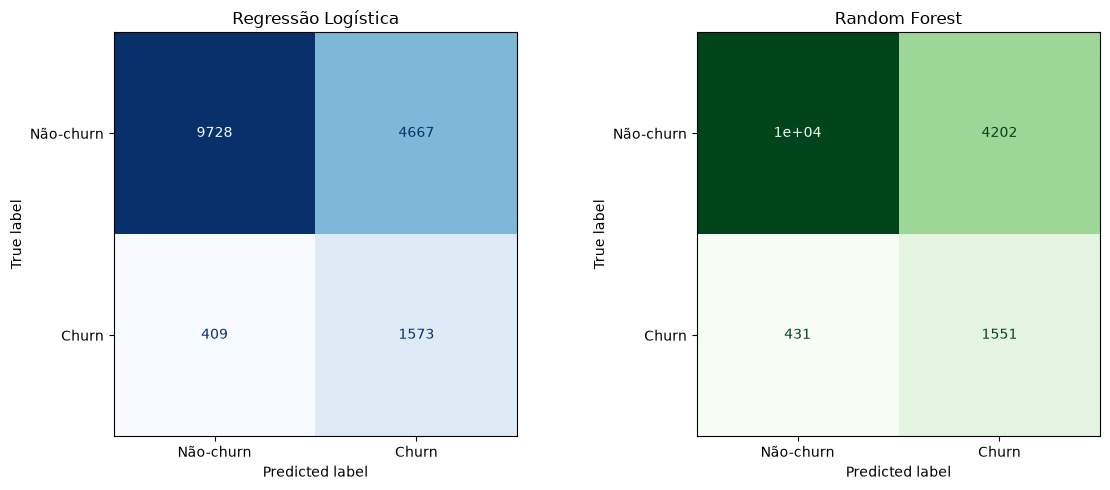

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm_lr, display_labels=["Não-churn", "Churn"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False
)
axes[0].set_title("Regressão Logística")

cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=["Não-churn", "Churn"]).plot(
    ax=axes[1], cmap="Greens", colorbar=False
)
axes[1].set_title("Random Forest")

plt.tight_layout()
plt.show()

12. CURVA ROC COMPARATIVA

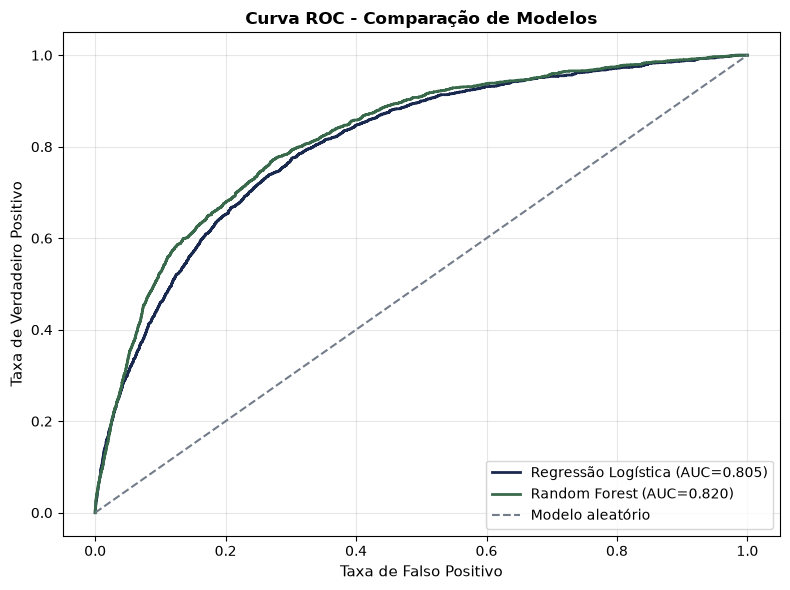

In [36]:
fig, ax = plt.subplots(figsize=(8, 6))

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

auc_lr = roc_auc_score(y_test, y_proba_lr)
auc_rf = roc_auc_score(y_test, y_proba_rf)

ax.plot(fpr_lr, tpr_lr, label=f"Regressão Logística (AUC={auc_lr:.3f})",
        color=PRT_NAVY, linewidth=2)
ax.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={auc_rf:.3f})",
        color=PRT_GREEN, linewidth=2)
ax.plot([0, 1], [0, 1], linestyle="--", color=PRT_GRAY, label="Modelo aleatório")

ax.set_xlabel("Taxa de Falso Positivo", fontsize=11)
ax.set_ylabel("Taxa de Verdadeiro Positivo", fontsize=11)
ax.set_title("Curva ROC - Comparação de Modelos", fontsize=12, fontweight="bold")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

13. FEATURE IMPORTANCE (RANDOM FOREST)

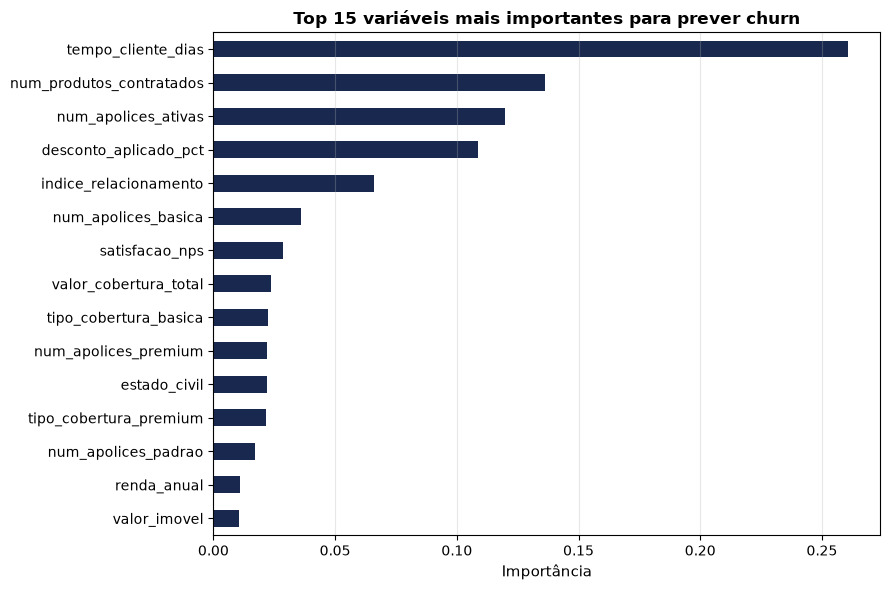


=== TOP 15 FEATURES ===
tempo_cliente_dias          0.260810
num_produtos_contratados    0.136098
num_apolices_ativas         0.119634
desconto_aplicado_pct       0.108832
indice_relacionamento       0.066131
num_apolices_basica         0.035839
satisfacao_nps              0.028764
valor_cobertura_total       0.023669
tipo_cobertura_basica       0.022385
num_apolices_premium        0.022213
estado_civil                0.021868
tipo_cobertura_premium      0.021752
num_apolices_padrao         0.016920
renda_anual                 0.010949
valor_imovel                0.010568
dtype: float64


In [37]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
importances.sort_values().plot(kind="barh", ax=ax, color=PRT_NAVY)
ax.set_title("Top 15 variáveis mais importantes para prever churn", fontsize=12, fontweight="bold")
ax.set_xlabel("Importância", fontsize=11)
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

print("\n=== TOP 15 FEATURES ===")
print(importances.sort_values(ascending=False))